# Data Analysis

The following data analysis was conducted by members of Ticknicians. The notebook cleans tick data, analyses and compares tick population against temperature, humidity, and precipitation.
Not all the graphs made here were used in the document. Also some graphs like linear regressions, were modified in place for the different sites ao that we don't have too many graphs taking up space.

Authors: Shobha Ratnam Priya, Tien Le, Shaarav Bhosale, Natalie Bowman, Kaitlyn Harrison

Date: 30 April 2025

**CLEANING TICK DATA**

In [ ]:
# Mount drive into CoLab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Change your directory by copy/pasting the path of your folder!
import os
os.chdir('/content/drive/MyDrive/Tick_Colab')
# Check to make sure you are in the right folder
!pwd

/content/drive/MyDrive/Tick_Colab


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
# read Tick Field Data
tick_field = pd.read_csv('tck_fielddata.csv')

In [ ]:
# read Tick Field Data
tick_field = pd.read_csv('tck_fielddata.csv')


In [ ]:
# Separate collectDate to Year, Month and Day – make a new column
tick_field["collectDate"] = pd.to_datetime(tick_field["collectDate"])
tick_field["year"] = pd.to_datetime(tick_field["collectDate"]).dt.year
tick_field["month"] = pd.to_datetime(tick_field["collectDate"]).dt.month
tick_field["day"] = pd.to_datetime(tick_field["collectDate"]).dt.day
# the data range is from 2014-2023

In [ ]:
# Remove Null(empty) values for where ticks counts are missing
# before: 2434 entries - after dropping N/A: 1145 entries
tick_field = tick_field.dropna(subset=['adultCount' , 'nymphCount', 'larvaCount'])

In [ ]:
# Create a new column that displays the state of the NEON site ( e.g. BART = Gradient Terrestrial, NH, D01: Northeast)
set(tick_field["siteID"])
# Unique sites: {'BART', 'GRSM', 'HARV', 'ORNL', 'TREE', 'UNDE'}

{'BART', 'GRSM', 'HARV', 'ORNL', 'TREE', 'UNDE'}

In [ ]:
# find total tick count
#tick_field['tickTotalCount'] = (
#    tick_field['adultCount'] +
#    tick_field['nymphCount'] +
#    tick_field['larvaCount'])
tick_field['tickTotalCount'] = (
    tick_field['adultCount'] +
    tick_field['nymphCount'])
# reset index
tick_field = tick_field.reset_index(drop=True)

In [ ]:
# Narrow down tick
tick_field_cleaned = tick_field[["siteID", "plotID", "year", "month", "day", "tickTotalCount"]]
tick_field_filtered = tick_field_cleaned[tick_field_cleaned['siteID'].isin(['ORNL', 'UNDE', 'HARV'])]

#Q1 = tick_field_cleaned["tickTotalCount"].quantile(0.25)
#Q3 = tick_field_cleaned["tickTotalCount"].quantile(0.75)
#IQR = Q3 - Q1

# Step 3: Define bounds for non-outliers
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR

# Step 4: Filter out outliers
#tick_field_cleaned = tick_field_cleaned[
#    (tick_field_cleaned["tickTotalCount"] >= lower_bound) &
#    (tick_field_cleaned["tickTotalCount"] <= upper_bound)
#]

<Axes: xlabel='year', ylabel='tickTotalCount'>

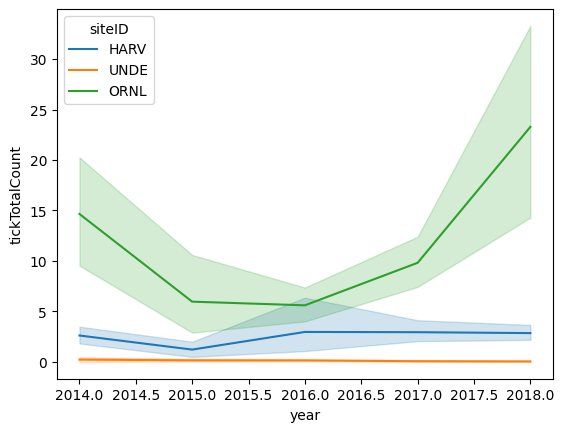

In [ ]:
sns.lineplot(x="year", y="tickTotalCount", data=tick_field_filtered, hue="siteID")

<Axes: xlabel='year', ylabel='tickTotalCount'>

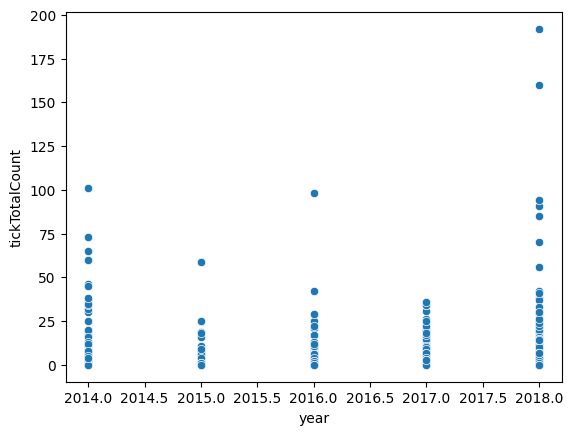

In [ ]:
sns.scatterplot(x="year", y="tickTotalCount", data=tick_field_cleaned)


<Axes: xlabel='year', ylabel='tickTotalCount'>

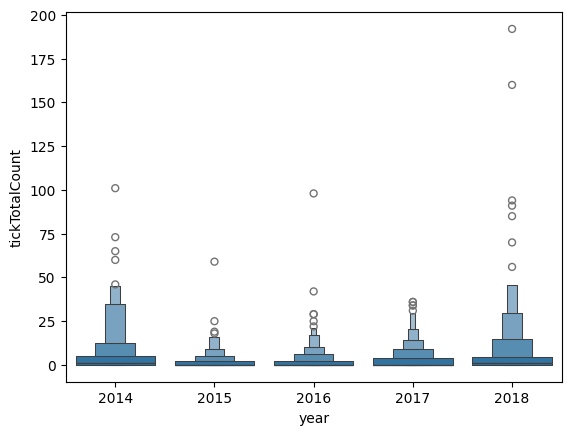

In [ ]:
sns.boxenplot(x="year", y="tickTotalCount", data=tick_field_cleaned)


<Axes: >

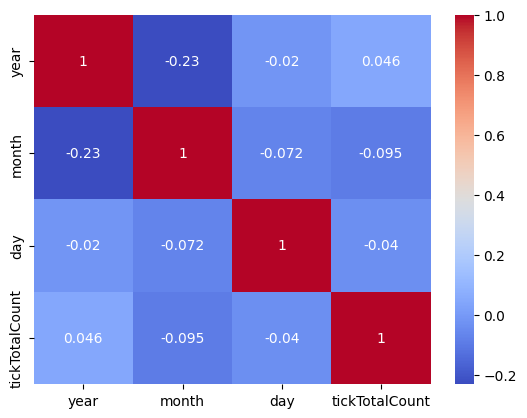

In [ ]:
#  merging weather variables & use this plot!!1
numeric_cols = tick_field_cleaned.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')


**COMPARING TICK DATA WITH TEMPERATURE**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10380 entries, 0 to 10379
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   domainID                10380 non-null  object 
 1   siteID                  10380 non-null  object 
 2   horizontalPosition      10380 non-null  int64  
 3   verticalPosition        10380 non-null  int64  
 4   date                    10380 non-null  object 
 5   wssTempTripleMean       9410 non-null   float64
 6   wssTempTripleMinimum    9410 non-null   float64
 7   wssTempTripleMaximum    9410 non-null   float64
 8   wssTempTripleVariance   9411 non-null   float64
 9   wssTempTripleStdErMean  9410 non-null   float64
 10  wssTempTripleNumPts     10380 non-null  int64  
 11  tempTripleQF            10380 non-null  int64  
 12  publicationDate         10380 non-null  object 
 13  release                 10380 non-null  object 
dtypes: float64(5), int64(4), object(5)
mem

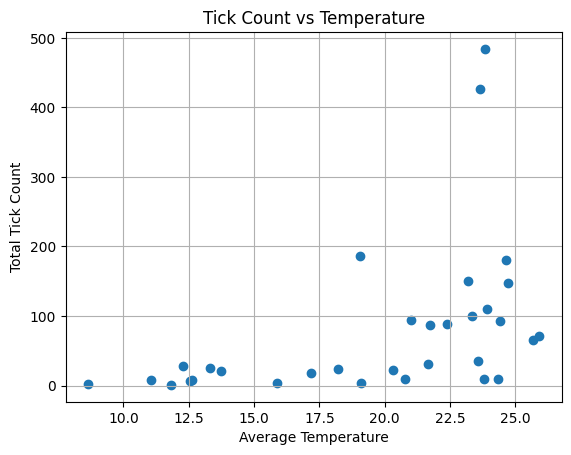

In [ ]:
#tick_field_cleaned.info()
# Read the daily temperature data from CSV file
d_temp = pd.read_csv("wss_daily_temp.csv")

# Display basic information about the temperature DataFrame
d_temp.info()

# Convert the 'date' column to datetime format
d_temp["Date"] = pd.to_datetime(d_temp["date"])

# Extract year, month, and day from the 'Date' column
d_temp["year"] = pd.to_datetime(d_temp["Date"]).dt.year
d_temp["month"] = pd.to_datetime(d_temp["Date"]).dt.month
d_temp["day"] = pd.to_datetime(d_temp["Date"]).dt.day

# Group tick data by site, year, and month, and sum the total tick count
tick_summary = (
    tick_field_cleaned
    .groupby(['siteID', 'year', 'month'], as_index=False)
    .agg(total_ticks=('tickTotalCount', 'sum'))
)

# Group temperature data by site, year, and month, and calculate average temperature
temp_summary = (
    d_temp
    .groupby(['siteID', 'year', 'month'], as_index=False)
    .agg(avg_temp=('wssTempTripleMean', 'mean'))
)

# Merge tick and temperature summaries on siteID, year, and month
merged_summary = tick_summary.merge(temp_summary, on=['siteID', 'year', 'month'], how='inner')

# Filter data for individual sites: ORNL, HARV, and UNDE
ornl_df = merged_summary[merged_summary['siteID'] == 'ORNL']
harv_df = merged_summary[merged_summary['siteID'] == 'HARV']
unde_df = merged_summary[merged_summary['siteID'] == 'UNDE']

# Plot scatter plot of average temperature vs total tick count for ORNL site
plt.scatter(ornl_df['avg_temp'], ornl_df['total_ticks'])
plt.xlabel('Average Temperature')
plt.ylabel('Total Tick Count')
plt.title('Tick Count vs Temperature')
plt.grid(True)
plt.show()

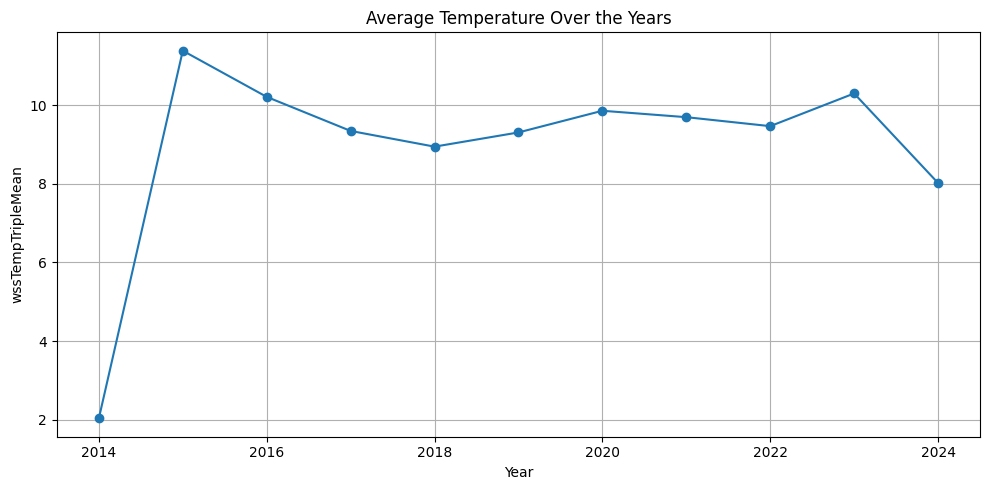

In [ ]:
# Calculate the first (Q1) and third (Q3) quartiles of the temperature data
Q1 = d_temp['wssTempTripleMean'].quantile(0.25)
Q3 = d_temp['wssTempTripleMean'].quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Define lower and upper bounds to identify outliers using the 1.5*IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers from the temperature data
d_temp_clean = d_temp[(d_temp['wssTempTripleMean'] >= lower_bound) &
                      (d_temp['wssTempTripleMean'] <= upper_bound)]

# Group temperature data by year and calculate the average temperature for each year
yearly_temp = d_temp.groupby('year')['wssTempTripleMean'].mean().reset_index()

# Plot the average temperature over the years
plt.figure(figsize=(10, 5))
plt.plot(yearly_temp['year'], yearly_temp['wssTempTripleMean'], marker='o')
plt.title('Average Temperature Over the Years')
plt.xlabel('Year')
plt.ylabel('wssTempTripleMean')
plt.grid(True)
plt.tight_layout()
plt.show()

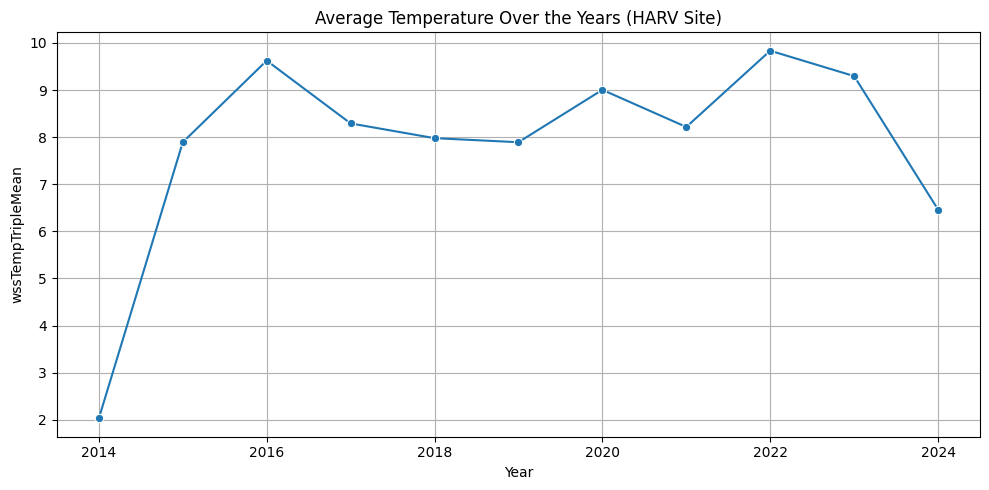

In [ ]:
# Filter the temperature dataset for individual sites: HARV, ORNL, and UNDE
harv_data = d_temp[d_temp['siteID'] == 'HARV']
ornl_data = d_temp[d_temp['siteID'] == 'ORNL']
unde_data = d_temp[d_temp['siteID'] == 'UNDE']

# Group data by year for each site and compute the average temperature per year
harv_yearly = harv_data.groupby('year')['wssTempTripleMean'].mean().reset_index()
ornl_yearly = ornl_data.groupby('year')['wssTempTripleMean'].mean().reset_index()
unde_yearly = unde_data.groupby('year')['wssTempTripleMean'].mean().reset_index()

# Plot the average yearly temperature trend for the HARV site using Seaborn
plt.figure(figsize=(10, 5))
sns.lineplot(data=harv_yearly, x='year', y='wssTempTripleMean', marker='o')
plt.title('Average Temperature Over the Years (HARV Site)')
plt.xlabel('Year')
plt.ylabel('wssTempTripleMean')
plt.grid(True)
plt.tight_layout()
plt.show()

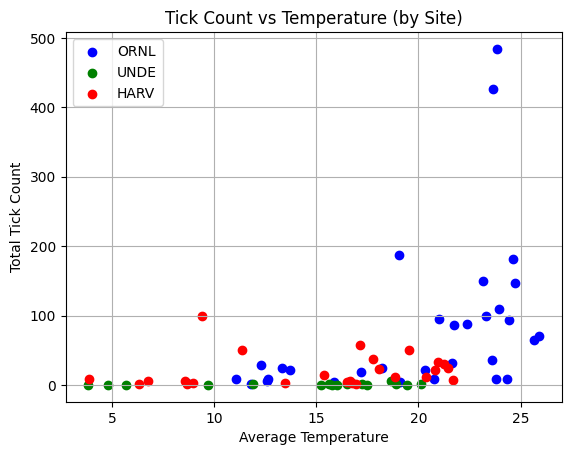

In [ ]:
# Filter the merged dataset to include only data from the ORNL, UNDE, and HARV sites
merged_summary_filtered = merged_summary[merged_summary['siteID'].isin(['ORNL', 'UNDE', 'HARV'])]

# Loop through each site and plot a scatter plot of average temperature vs total tick count
# Assign a unique color and label for each site
for site, color in zip(['ORNL', 'UNDE', 'HARV'], ['blue', 'green', 'red']):
    site_data = merged_summary_filtered[merged_summary_filtered['siteID'] == site]
    plt.scatter(site_data['avg_temp'], site_data['total_ticks'], color=color, label=site)

# Add labels, title, legend, and grid to the plot
plt.xlabel('Average Temperature')
plt.ylabel('Total Tick Count')
plt.title('Tick Count vs Temperature (by Site)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
temp_summary

,siteID,year,month,avg_temp
0,HARV,2014,10,8.568791
1,HARV,2014,11,2.334487
2,HARV,2014,12,-0.581826
3,HARV,2015,1,-7.246455
4,HARV,2015,2,-10.628768
...,...,...,...,...
338,UNDE,2024,2,-2.624024
339,UNDE,2024,3,-0.769532
340,UNDE,2024,4,5.646865
341,UNDE,2024,5,12.385055


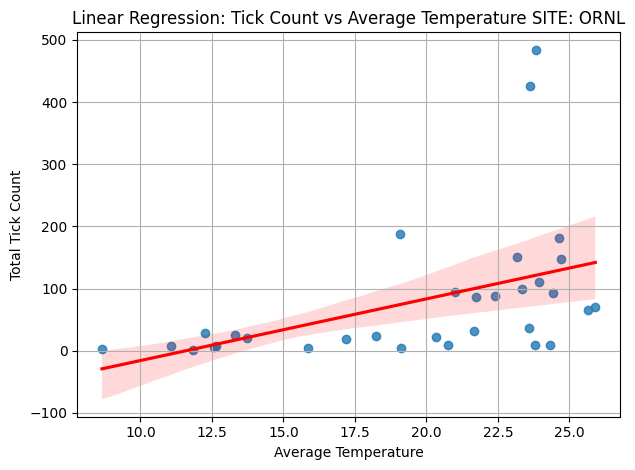

Slope: 9.920938949111541


In [ ]:
from scipy.stats import linregress

# Create a regression plot for the ORNL site showing the relationship between average temperature and total tick count
plt.figure()
sns.regplot(
    data=ornl_df,
    x='avg_temp',  # Independent variable
    y='total_ticks',  # Dependent variable
    scatter=True,     # Display individual data points
    ci=95,            # 95% confidence interval for the regression line
    line_kws={"color": "red"}  # Set color of the regression line
)
plt.xlabel('Average Temperature')
plt.ylabel('Total Tick Count')
plt.title('Linear Regression: Tick Count vs Average Temperature SITE: ORNL')
plt.grid(True)
plt.tight_layout()
plt.show()

# Perform a linear regression analysis using scipy to get slope, intercept, R-value, etc.
slope, intercept, r_value, p_value, std_err = linregress(ornl_df['avg_temp'], ornl_df['total_ticks'])

# Print the slope of the regression line to understand the rate of change in tick count with temperature
print("Slope:", slope)


<Axes: xlabel='month', ylabel='wssTempTripleMean'>

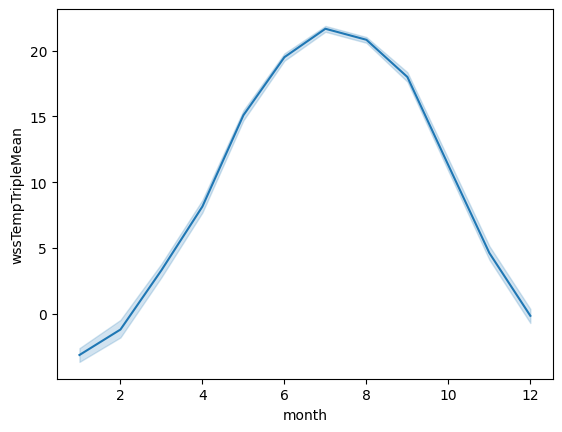

In [ ]:
# Drop rows with missing values in the 'wssTempTripleMean' column to ensure clean temperature data
daily_temp = d_temp.dropna(subset=['wssTempTripleMean'])

# Plot the average daily temperature trend over months using a line plot
# This helps identify seasonal temperature patterns across the year
sns.lineplot(x="month", y="wssTempTripleMean", data=daily_temp)

**COMPARING TICK COUNT WITH HUMIDITY**

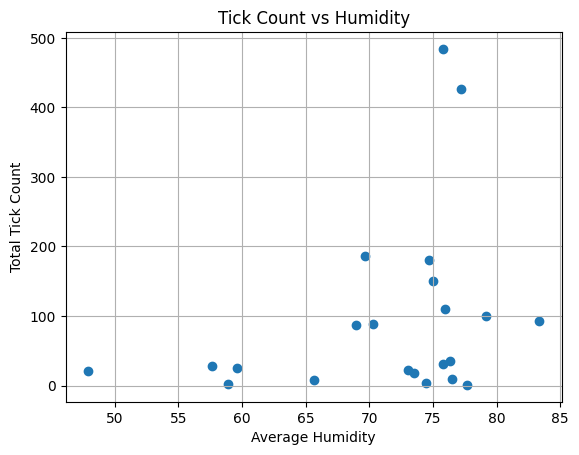

In [ ]:
# Read daily humidity data from CSV
d_humid = pd.read_csv("wss_daily_humid.csv")

# Convert the 'date' column to datetime format
d_humid["Date"] = pd.to_datetime(d_humid["date"])

# Extract year, month, and day from the 'Date' column
d_humid["year"] = d_humid["Date"].dt.year
d_humid["month"] = d_humid["Date"].dt.month
d_humid["day"] = d_humid["Date"].dt.day

# Group humidity data by site, year, and month to calculate average monthly humidity
humid_summary = (
    d_humid
    .groupby(['siteID', 'year', 'month'], as_index=False)
    .agg(avg_humid=('wssRHMean', 'mean'))
)

# Merge humidity summary with tick count summary on site, year, and month
merged_humid = tick_summary.merge(humid_summary, on=['siteID', 'year', 'month'], how='inner')

# Filter merged data for each site individually
ornl_h = merged_humid[merged_humid['siteID'] == 'ORNL']
harv_h = merged_humid[merged_humid['siteID'] == 'HARV']
unde_h = merged_humid[merged_humid['siteID'] == 'UNDE']

# Plot tick count vs. humidity for ORNL site
plt.scatter(ornl_h['avg_humid'], ornl_h['total_ticks'])
plt.xlabel('Average Humidity')
plt.ylabel('Total Tick Count')
plt.title('Tick Count vs Humidity')
plt.grid(True)
plt.show()


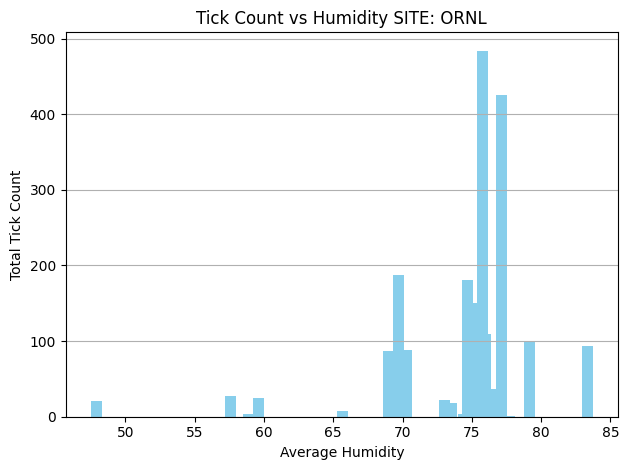

In [ ]:
# Sort merged humidity data by average humidity for cleaner bar plots
merged_humid_sorted = merged_humid.sort_values(by='avg_humid')
ornl_h_sorted = ornl_h.sort_values(by='avg_humid')
harv_h_sorted = harv_h.sort_values(by='avg_humid')
unde_h_sorted = unde_h.sort_values(by='avg_humid')

# Plot bar graph of average humidity vs. tick count for ORNL site
plt.bar(ornl_h_sorted['avg_humid'], ornl_h_sorted['total_ticks'], color='skyblue')
plt.xlabel('Average Humidity')  # X-axis label
plt.ylabel('Total Tick Count')  # Y-axis label
plt.title('Tick Count vs Humidity SITE: ORNL')  # Plot title
plt.grid(axis='y')  # Show horizontal grid lines for readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plot


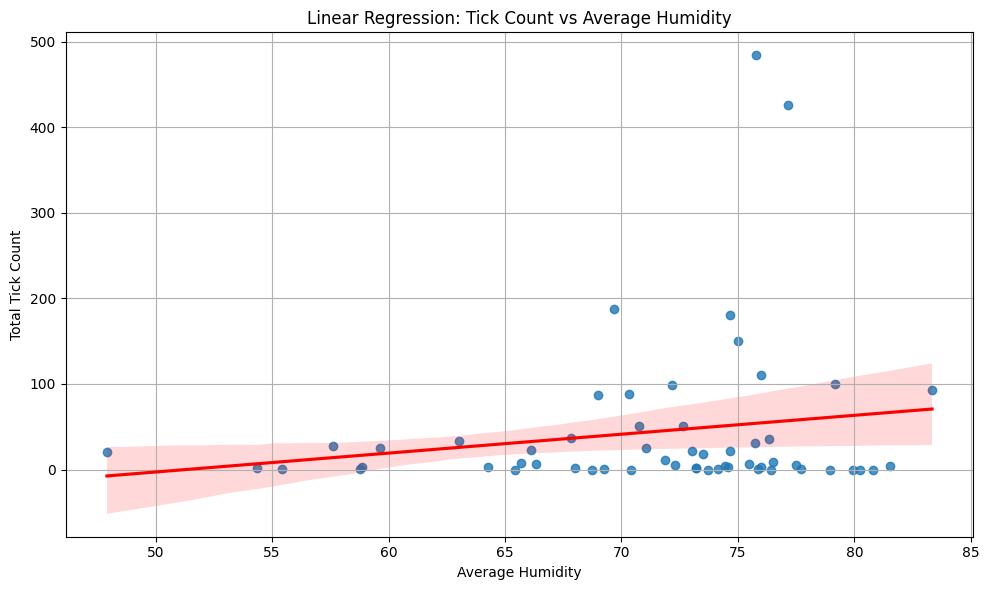

In [ ]:
# Create a figure with specified size for better visibility
plt.figure(figsize=(10, 6))

# Plot a linear regression line with scatter points showing relationship between humidity and tick count
sns.regplot(
    data=merged_humid,                 # Data source
    x='avg_humid',                     # X-axis: average humidity
    y='total_ticks',                   # Y-axis: total tick count
    scatter=True,                      # Display scatter plot points
    ci=95,                             # 95% confidence interval for the regression line
    line_kws={"color": "red"}          # Style the regression line in red
)

# Add axis labels and title to the plot
plt.xlabel('Average Humidity')
plt.ylabel('Total Tick Count')
plt.title('Linear Regression: Tick Count vs Average Humidity')

# Display gridlines and format layout
plt.grid(True)
plt.tight_layout()

# Render the plot
plt.show()


<Axes: xlabel='month', ylabel='wssRHMean'>

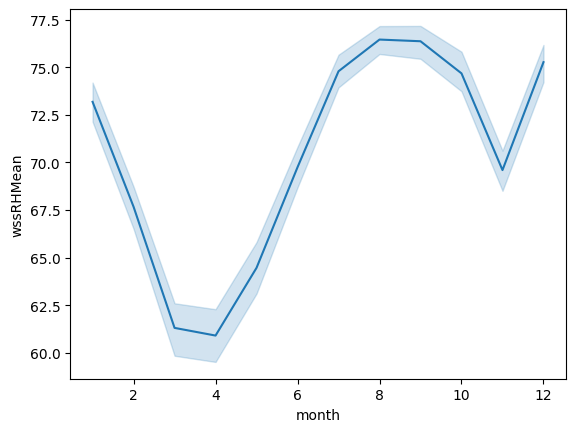

In [ ]:
daily_humid = d_humid.dropna(subset=['wssRHMean'])
sns.lineplot(x="month", y="wssRHMean", data=daily_humid)


(TEMPERATURE COMPARISON AGAIN)

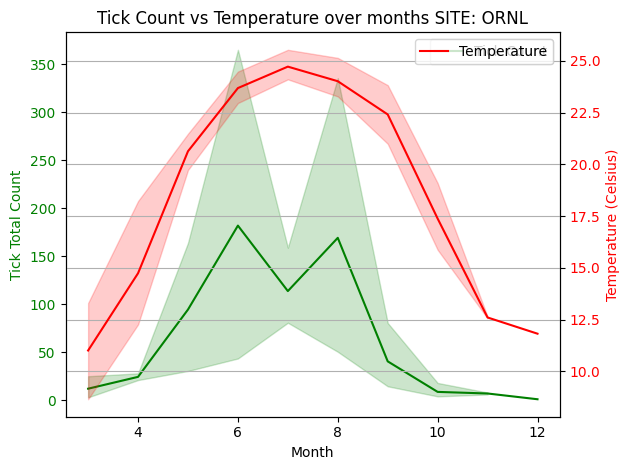

In [ ]:
fig, ax1 = plt.subplots()

# Plot tick total count on primary y-axis
sns.lineplot(x="month", y="total_ticks", data=ornl_df, ax=ax1, color='green', label='Tick Count')
ax1.set_ylabel('Tick Total Count', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Month')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot temperature on secondary y-axis
sns.lineplot(x="month", y="avg_temp", data=ornl_df, ax=ax2, color='red', label='Temperature')
ax2.set_ylabel('Temperature (Celsius)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and layout
plt.title('Tick Count vs Temperature over months SITE: ORNL')
fig.tight_layout()
plt.grid(True)
plt.show()

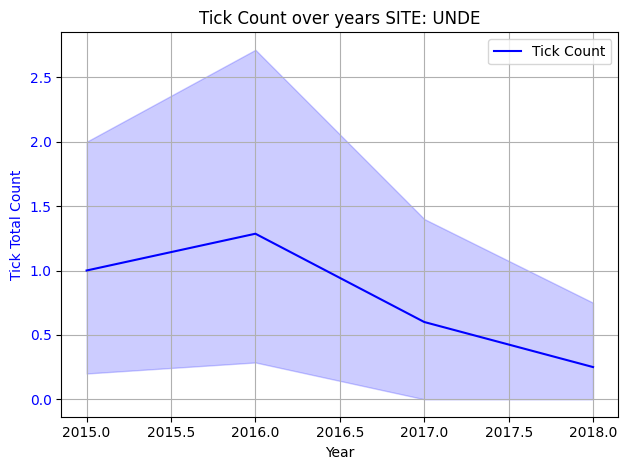

In [ ]:
fig, ax1 = plt.subplots()

# Plot tick total count on primary y-axis
sns.lineplot(x="year", y="total_ticks", data=unde_df, ax=ax1, color='blue', label='Tick Count')
ax1.set_ylabel('Tick Total Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Year')

plt.title('Tick Count over years SITE: UNDE')
fig.tight_layout()
plt.grid(True)
plt.show()

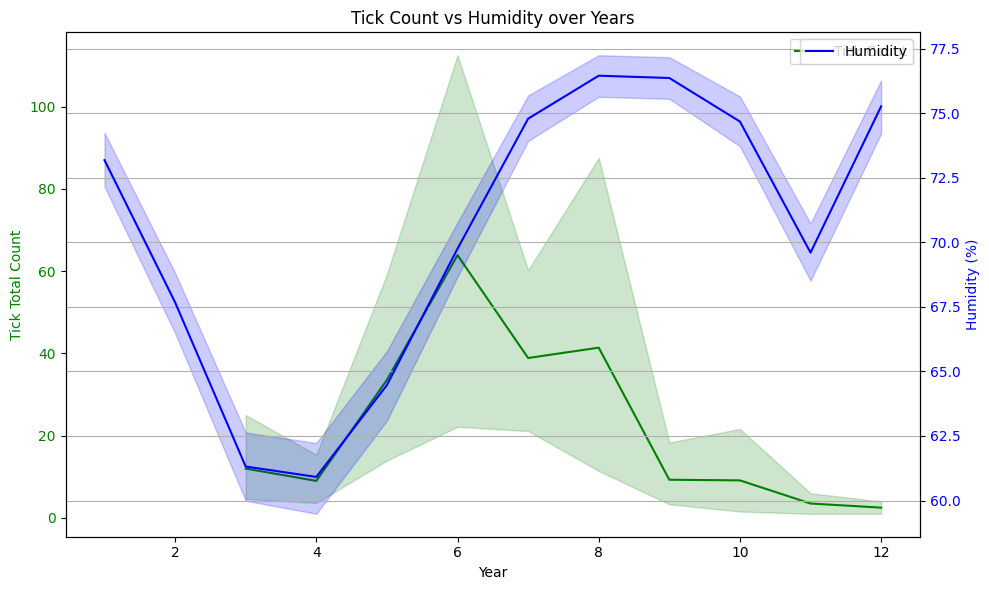

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Tick total count
sns.lineplot(x="month", y="total_ticks", data=tick_summary, ax=ax1, color='green', label='Tick Count')
ax1.set_ylabel('Tick Total Count', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Year')

# Secondary y-axis: Humidity
ax2 = ax1.twinx()
sns.lineplot(x="month", y="wssRHMean", data=daily_humid, ax=ax2, color='blue', label='Humidity')
ax2.set_ylabel('Humidity (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Title and layout
plt.title('Tick Count vs Humidity over Years')
plt.grid(True)
fig.tight_layout()
plt.show()

**COMPARING TICK COUNT WITH PRESSURE** (NOT USED)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10380 entries, 0 to 10379
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   domainID             10380 non-null  object 
 1   siteID               10380 non-null  object 
 2   horizontalPosition   10380 non-null  int64  
 3   verticalPosition     10380 non-null  int64  
 4   date                 10380 non-null  object 
 5   wssStaPresMean       9637 non-null   float64
 6   wssStaPresMinimum    9637 non-null   float64
 7   wssStaPresMaximum    9637 non-null   float64
 8   wssStaPresVariance   9644 non-null   float64
 9   wssStaPresStdErMean  9637 non-null   float64
 10  wssStaPresNumPts     10380 non-null  int64  
 11  staPresQF            10380 non-null  int64  
 12  wssCorPres           8706 non-null   float64
 13  corPresQF            10380 non-null  int64  
 14  publicationDate      10380 non-null  object 
 15  release              10380 non-null 

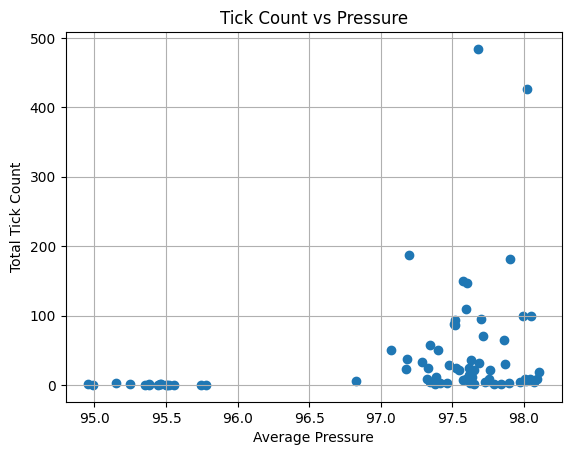

In [ ]:
# Read the daily pressure data from CSV and check the info
d_pres = pd.read_csv("wss_daily_pres.csv")
d_pres.info()

# Convert 'date' column to datetime format and extract year, month, and day components
d_pres["Date"] = pd.to_datetime(d_pres["date"])
d_pres["year"] = pd.to_datetime(d_pres["Date"]).dt.year
d_pres["month"] = pd.to_datetime(d_pres["Date"]).dt.month
d_pres["day"] = pd.to_datetime(d_pres["Date"]).dt.day

# Group the pressure data by siteID, year, and month, then calculate the average pressure
pres_summary = (
    d_pres
    .groupby(['siteID', 'year', 'month'], as_index=False)
    .agg(avg_humid=('wssStaPresMean', 'mean'))  # Rename column to avg_humid for consistency
)

# Merge the tick data with the pressure data based on site, year, and month
merged_pres = tick_summary.merge(pres_summary, on=['siteID', 'year', 'month'], how='inner')

# Create a scatter plot to visualize the relationship between average pressure and total tick count
plt.scatter(merged_pres['avg_humid'], merged_pres['total_ticks'])
plt.xlabel('Average Pressure')  # X-axis label
plt.ylabel('Total Tick Count')  # Y-axis label
plt.title('Tick Count vs Pressure')  # Plot title
plt.grid(True)  # Display gridlines for easier visualization
plt.show()  # Display the plot


**COMPARING TICK COUNT WITH PRECIPITATION**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191976 entries, 0 to 191975
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   domainID             191976 non-null  object 
 1   siteID               191976 non-null  object 
 2   horizontalPosition   191976 non-null  int64  
 3   verticalPosition     191976 non-null  int64  
 4   startDateTime        191976 non-null  object 
 5   endDateTime          191976 non-null  object 
 6   precipBulk           156249 non-null  float64
 7   precipBulkExpUncert  156249 non-null  float64
 8   finalQF              191976 non-null  int64  
 9   publicationDate      191976 non-null  object 
 10  release              191976 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 16.1+ MB


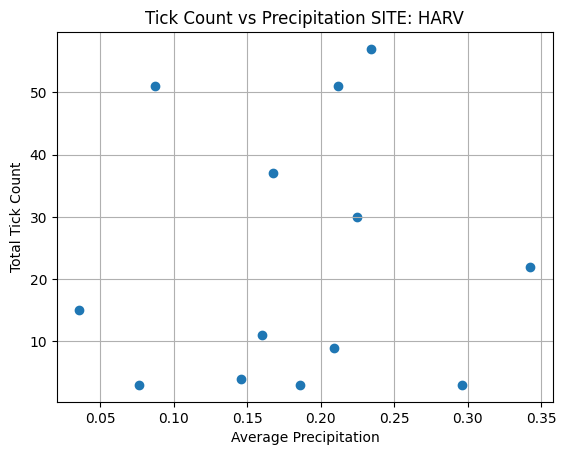

In [ ]:
# Read the precipitation data from CSV and check the info
d_precip = pd.read_csv("WEIPRE_60min.csv")
d_precip.info()

# Convert 'endDateTime' column to datetime format and extract year, month, and day components
d_precip["Date"] = pd.to_datetime(d_precip["endDateTime"])
d_precip["year"] = pd.to_datetime(d_precip["Date"]).dt.year
d_precip["month"] = pd.to_datetime(d_precip["Date"]).dt.month
d_precip["day"] = pd.to_datetime(d_precip["Date"]).dt.day

# Group the precipitation data by siteID, year, and month, then calculate the average precipitation
precip_summary = (
    d_precip
    .groupby(['siteID', 'year', 'month'], as_index=False)
    .agg(avg_precip=('precipBulk', 'mean'))  # Rename column to avg_precip for consistency
)

# Merge the tick data with the precipitation data based on site, year, and month
merged_precip = tick_summary.merge(precip_summary, on=['siteID', 'year', 'month'], how='inner')

# Filter the data for the specific site 'HARV'
harv_p = merged_precip[merged_precip['siteID'] == 'HARV']

# Create a scatter plot to visualize the relationship between average precipitation and total tick count for 'HARV'
plt.scatter(harv_p['avg_precip'], harv_p['total_ticks'])
plt.xlabel('Average Precipitation')  # X-axis label
plt.ylabel('Total Tick Count')  # Y-axis label
plt.title('Tick Count vs Precipitation SITE: HARV')  # Plot title
plt.grid(True)  # Display gridlines for easier visualization
plt.show()  # Display the plot


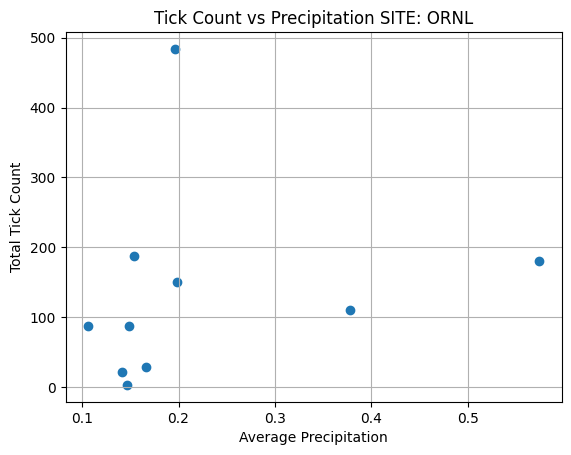

In [ ]:
# Filter the data for the specific site 'ORNL'
ornl_p = merged_precip[merged_precip['siteID'] == 'ORNL']

# Create a scatter plot to visualize the relationship between average precipitation and total tick count for 'ORNL'
plt.scatter(ornl_p['avg_precip'], ornl_p['total_ticks'])
plt.xlabel('Average Precipitation')  # X-axis label
plt.ylabel('Total Tick Count')  # Y-axis label
plt.title('Tick Count vs Precipitation SITE: ORNL')  # Plot title
plt.grid(True)  # Display gridlines for easier visualization
plt.show()  # Display the plot

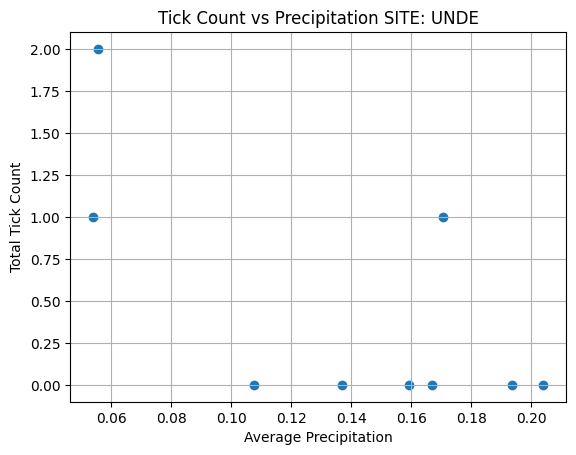

In [ ]:
# Filter the data for the specific site 'UNDE'
unde_p = merged_precip[merged_precip['siteID'] == 'UNDE']

# Create a scatter plot to visualize the relationship between average precipitation and total tick count for 'UNDE'
plt.scatter(unde_p['avg_precip'], unde_p['total_ticks'])
plt.xlabel('Average Precipitation')  # X-axis label
plt.ylabel('Total Tick Count')  # Y-axis label
plt.title('Tick Count vs Precipitation SITE: UNDE')  # Plot title
plt.grid(True)  # Display gridlines for easier visualization
plt.show()  # Display the plot

Text(0.5, 1.0, 'Tick Count vs Precipitation')

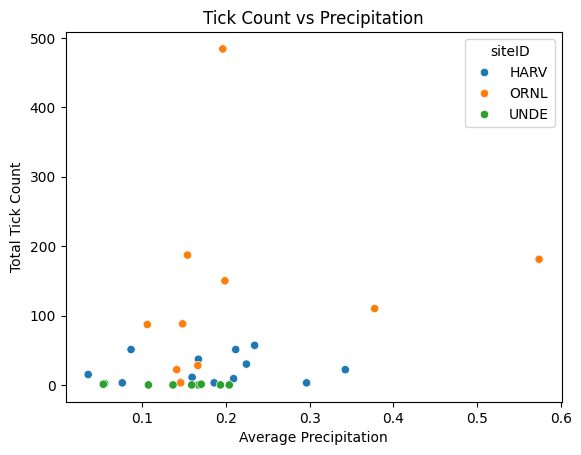

In [ ]:
allsites_p = merged_precip[merged_precip['siteID'].isin(['HARV', 'ORNL', 'UNDE'])]

# Create a scatter plot to visualize the relationship between average precipitation and total tick count for all three sites
sns.scatterplot(data=allsites_p, x='avg_precip', y='total_ticks', hue='siteID')
plt.xlabel('Average Precipitation')  # X-axis label
plt.ylabel('Total Tick Count')  # Y-axis label
plt.title('Tick Count vs Precipitation')  # Plot title

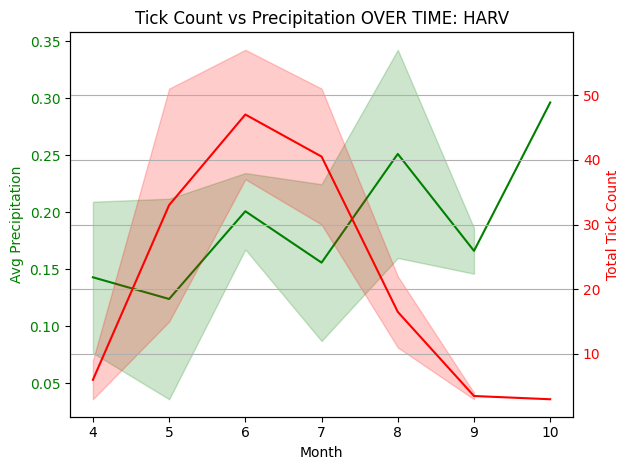

In [ ]:
# PRECIPITATION VS TICK COUNT TIME SERIES: HARV
allsites_p = merged_precip[merged_precip['siteID'].isin(['HARV'])]

fig, ax1 = plt.subplots()

# Create a scatter plot to visualize the relationship between average precipitation and total tick count for all three sites
sns.lineplot(data=allsites_p, x='month', y='avg_precip', ax=ax1, color = 'green')
ax1.set_ylabel('Avg Precipitation', color = 'green')  # Y-axis label
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Month')  # X-axis label


ax2 = ax1.twinx()
sns.lineplot(data=allsites_p, x='month', y='total_ticks', ax=ax2, color = 'red')
ax2.set_ylabel('Total Tick Count', color = 'red')  # Y-axis label
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Tick Count vs Precipitation OVER TIME: HARV')
plt.grid(True)
fig.tight_layout()
plt.show()



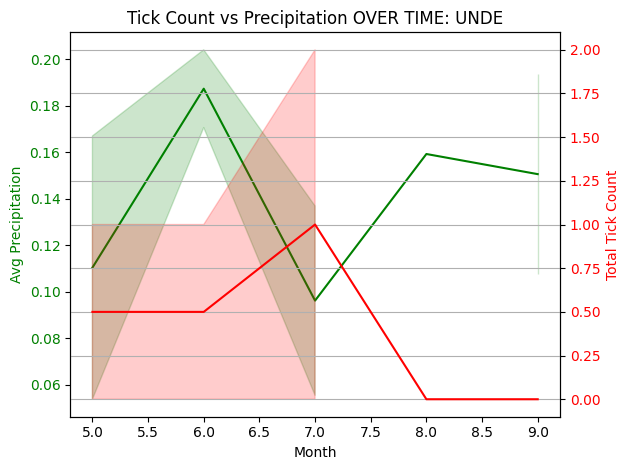

In [ ]:
# PRECIPITATION VS TICK COUNT TIME SERIES UNDE
allsites_p = merged_precip[merged_precip['siteID'].isin(['UNDE'])]

fig, ax1 = plt.subplots()

# Create a scatter plot to visualize the relationship between average precipitation and total tick count for all three sites
sns.lineplot(data=allsites_p, x='month', y='avg_precip', ax=ax1, color = 'green')
ax1.set_ylabel('Avg Precipitation', color = 'green')  # Y-axis label
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Month')  # X-axis label


ax2 = ax1.twinx()
sns.lineplot(data=allsites_p, x='month', y='total_ticks', ax=ax2, color = 'red')
ax2.set_ylabel('Total Tick Count', color = 'red')  # Y-axis label
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Tick Count vs Precipitation OVER TIME: UNDE')
plt.grid(True)
fig.tight_layout()
plt.show()



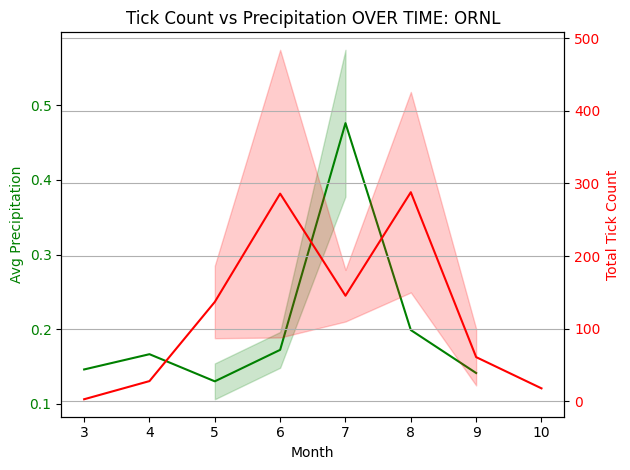

In [ ]:
# PRECIPITATION VS TICK COUNT TIME SERIES: ORNL
allsites_p = merged_precip[merged_precip['siteID'].isin(['ORNL'])]

fig, ax1 = plt.subplots()

# Create a scatter plot to visualize the relationship between average precipitation and total tick count for all three sites
sns.lineplot(data=allsites_p, x='month', y='avg_precip', ax=ax1, color = 'green')
ax1.set_ylabel('Avg Precipitation', color = 'green')  # Y-axis label
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Month')  # X-axis label


ax2 = ax1.twinx()
sns.lineplot(data=allsites_p, x='month', y='total_ticks', ax=ax2, color = 'red')
ax2.set_ylabel('Total Tick Count', color = 'red')  # Y-axis label
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Tick Count vs Precipitation OVER TIME: ORNL')
plt.grid(True)
fig.tight_layout()
plt.show()

